In [76]:
import sys
import glob
import pickle
import numpy as np
import pandas as pd
from functools import reduce
import matplotlib.pyplot as plt

sys.path.append("/mnt/lareaulab/reliscu/programs/FGP_2024")
sys.path.append("/mnt/lareaulab/reliscu/projects/Chronocell/analyses/simulations/code")

import Chronocell
from simulate_data import *

In [77]:
prefix = "janssens_2025_preprint_Chronocell_eLNPs_var>1.5"

In [78]:
# Genes in Chronocell object (column order)
chronocell_genes = pd.read_csv(f"data/{prefix}_traj_X_colnames.csv") 

 # Subset to genes with  protein measurements
mapped_identifiers = pd.read_csv("data/janssens_2025_preprint_author_counts_eLNP_RNA_vs_ADT_corrs.csv")
mask = chronocell_genes['Gene_symbol'].isin(mapped_identifiers['Gene']).tolist()

# Subset Chronocell genes to those in X_fwd object
traj_genes = chronocell_genes.iloc[mask]

In [79]:
# Get traj object from running Chronocell
import pickle
with open(f"data/{prefix}_traj_WS.pkl", "rb") as f:
    traj = pickle.load(f)

In [80]:
# Subset traj object to genes of interest

Y = traj.X
Q = traj.Q[:, 0, :] 
tau = traj.tau # State transition times (global)
t = traj.t
theta = traj.theta
topo = traj.topo

Y = Y[:, mask, :]
theta = theta[mask, :]
theta_ = theta.copy()
a0 = theta_[:, 0] # Starting RNA abundance 
a = theta_[:, 1:len(topo.flatten())] 
beta = theta_[:, -2] # Splicing rate
alpha = a * beta[:, None] # Transcription rates are normalized by splicing rate; removing this factor now
gamma = theta_[:, -1] # Degradation rate

In [81]:
traj_genes

,Gene_symbol
3,Cxcr4
9,Icos
12,Cd48
17,Cd24a
21,Cd63
24,Cd68
27,Ccr7
29,Cd300c2
33,Havcr2
48,Ighm


In [82]:
# Get X_fwd for each gene (order matches traj_genes order)

import pickle
with open(f"data/{prefix}_X_fwd_per_gene.pkl", "rb") as f:
    X_fwd_per_gene = pickle.load(f)

import pickle
with open(f"data/{prefix}_states_per_gene.pkl", "rb") as f:
    states_per_gene = pickle.load(f)

## Get half-life data

In [83]:
data_dir = "/mnt/lareaulab/reliscu/projects/Chronocell/data/experimental_parameters/protein_degradation_rates"
file_list = glob.glob(f"{data_dir}/*standardized.csv")

# Don't include brain samples because half lives are super long / doesn't seem representative
exclude = ["Cerebellum", "Cortex"]
file_list = [f for f in file_list if not any(term in f for term in exclude)]

subset_columns = ['Gene', 'Half-life']

df_list = []
for file in [file for file in file_list if "Mouse" in file]:
    df = pd.read_csv(file)
    study = df['Study'].iloc[0]
    cell_type = df['Cell_type'].iloc[0]
    df = df[subset_columns]
    df = df.rename(columns={"Half-life": f"Half-life_{study}_{cell_type}", 
                            "Cell_type": f"Cell_type_{study}"}) 
    df_list.append(df)

In [84]:
df_list[0].head()

,Gene,Half-life_McShane2016_NIH3T3 fibroblasts
0,Cul4b,31.378265
1,Dhx8,28.700000
2,Znf335,3.599724
3,Arfgef2,24.371302
4,Cdc27,21.057713


In [85]:
df = reduce(lambda x, y: pd.merge(x, y, on="Gene", how="outer"), df_list)

##### Subset half-life data to genes of interest

In [86]:
deg_rate_df = df.loc[df['Gene'].isin(traj_genes['Gene_symbol'])]

In [87]:
deg_rate_df

,Gene,Half-life_McShane2016_NIH3T3 fibroblasts,Half-life_Schwanhausser2011_NIH3T3 fibroblasts,Half-life_Fornasiero2018_Leg-muscle,Half-life_Matsuda2024_Induced presomitic mesoderm cells,Half-life_Cambridge2011_C2C12 myoblasts,Half-life_Mathieson2018_Embryonic neurons,Half-life_Fornasiero2018_Heart
1962,Bst2,NaN,8.89,NaN,NaN,NaN,NaN,NaN
2973,Cd63,19.953640,57.49,NaN,NaN,NaN,NaN,NaN
2976,Cd9,NaN,32.19,NaN,NaN,NaN,NaN,NaN
7683,Itgb1,63.400000,11.75,60.0,NaN,28.3,NaN,62.88
8793,Lamp1,NaN,30.18,NaN,NaN,38.7,NaN,35.04
8875,Lgals3,115.005279,60.99,NaN,NaN,44.3,NaN,NaN
11057,Notch2,9.629458,6.13,NaN,NaN,15.6,NaN,NaN
12968,Procr,NaN,22.27,NaN,NaN,NaN,NaN,NaN
18975,Vcam1,12.751839,18.18,NaN,NaN,15.5,NaN,NaN


#### Get order of genes in half-life data

In [88]:
deg_rate_genes = deg_rate_df['Gene'].tolist() # List of genes with half-life data
 
# Get index for which half life genes appear in X_bw_per_gene; index X_bw_per_gene in this order 
gene_order_idx = pd.Index(traj_genes['Gene_symbol']).get_indexer(deg_rate_genes)

In [89]:
traj_genes['Gene_symbol']

3         Cxcr4
9          Icos
12         Cd48
17        Cd24a
21         Cd63
24         Cd68
27         Ccr7
29      Cd300c2
33       Havcr2
48         Ighm
59         Irf4
63         Cd83
70       Lgals3
73         Il7r
82         Ly6e
88         Cd86
90        Cd200
93         Cd80
94         Btla
107       Ms4a1
109       Cd274
110         Fas
114      Entpd1
117        Dpp4
127       Itga4
129       Procr
135       Cd1d1
138       Vcam1
141      Notch2
150     Tnfrsf4
151    Tnfrsf18
152        Cd36
157        Flt3
158        Cd38
159         Kit
164       Cd207
167         Cd9
170       Klrk1
174        Cd8a
176     Clec12a
177      Clec9a
179        Pirb
182       Il4ra
183       Itgal
184       Itgax
186        Bst2
190       Lamp1
194       Itgb1
196        Fut4
201        Xcr1
203       Icam1
205        Jaml
Name: Gene_symbol, dtype: object

In [90]:
deg_rate_genes

['Bst2', 'Cd63', 'Cd9', 'Itgb1', 'Lamp1', 'Lgals3', 'Notch2', 'Procr', 'Vcam1']

In [91]:
gene_order_idx

array([45,  4, 36, 47, 46, 12, 28, 25, 27])

#### Convert half-life to degradation rate

In [92]:
half_life_cols = [col for col in deg_rate_df.columns if "Half-life" in col]
df_deg = np.log(2)/deg_rate_df[half_life_cols]

# Match order to order of genes in 
median_deg = np.nanmedian(df_deg, axis=1)

In [93]:
deg_rate_df['Gene']

1962       Bst2
2973       Cd63
2976        Cd9
7683      Itgb1
8793      Lamp1
8875     Lgals3
11057    Notch2
12968     Procr
18975     Vcam1
Name: Gene, dtype: object

## Impute protein

In [94]:
t_l = np.repeat(0, len(t))

P_imputed = np.empty((len(t), len(gene_order_idx)))

for idx, value in enumerate(gene_order_idx):
    print(traj_genes.iloc[value])
    print(deg_rate_df['Gene'].iloc[idx]) 
    
    phi = np.zeros((1, 2))
    phi[:,0] = 1 
    phi[:,-1] = median_deg[idx]
    
    X_fwd = X_fwd_per_gene[value]
    states = np.asarray(states_per_gene[value])
    
    # Get most probable state for spliced RNA at each time point
    Y = states[X_fwd.argmax(axis=0)]
    Y = Y[:, None, :]
    
    P_observed, P = simulate_protein_from_RNA(Y, topo, t, t_l, phi, random_seed=0)
    
    P_imputed[:, idx] = P.flatten()

Gene_symbol    Bst2
Name: 186, dtype: object
Bst2
Gene_symbol    Cd63
Name: 21, dtype: object
Cd63
Gene_symbol    Cd9
Name: 167, dtype: object
Cd9
Gene_symbol    Itgb1
Name: 194, dtype: object
Itgb1
Gene_symbol    Lamp1
Name: 190, dtype: object
Lamp1
Gene_symbol    Lgals3
Name: 70, dtype: object
Lgals3
Gene_symbol    Notch2
Name: 141, dtype: object
Notch2
Gene_symbol    Procr
Name: 129, dtype: object
Procr
Gene_symbol    Vcam1
Name: 138, dtype: object
Vcam1


## Compare imputed data to observed data

In [34]:
sampleinfo = pd.read_csv(f"data/{prefix}_traj_X_row_metadata.csv")
orig_corr = pd.read_csv("data/janssens_2025_preprint_author_counts_eLNP_RNA_vs_ADT_corrs.csv")

expr_ADT = pd.read_csv("data/janssens_2025_preprint_author_ADT_counts_eLNP.csv", index_col=0)
expr_RNA = pd.read_csv("data/janssens_2025_preprint_author_RNA_counts_eLNP.csv", index_col=0)

expr_ADT.index = expr_ADT.index.str.replace("-1", "", regex=False)
expr_ADT.index = expr_ADT.index.str.replace("_", "-", regex=False)

expr_RNA.index = expr_RNA.index.str.replace("-1", "", regex=False)
expr_RNA.index = expr_RNA.index.str.replace("_", "-", regex=False)

In [35]:
Q_idx_per_cell = Q.argmax(axis=1) # Time (index) each cell was assigned to

t_per_cell = t[np.sort(Q_idx_per_cell)] # Timepoint of each cell 
cell_order_idx = np.argsort(Q_idx_per_cell) # Cell ordering 
cell_index = expr_ADT.index[cell_order_idx] # Ordered Cell IDs

# Order cells according to their place in time
expr_ADT_ordered = expr_ADT.loc[cell_index]
expr_RNA_ordered = expr_RNA.loc[cell_index]

## Plot

In [193]:
# Gene to plot
gene_idx = 5
gene = deg_rate_df['Gene'].iloc[gene_idx]
print(gene)
prot = orig_corr.loc[orig_corr['Gene'].isin([gene]), 'Protein']

Lgals3


In [194]:
gene_order_idx[gene_idx]

np.int64(12)

In [195]:
# Forward data for gene
value = gene_order_idx[gene_idx]
X_fwd = X_fwd_per_gene[value]
states = np.asarray(states_per_gene[value])
# Get most probable state for spliced RNA at each time point
Y_fwd = states[X_fwd.argmax(axis=0)]

In [196]:
# Backward data for working gene (for each cell)
file_path = f"data/RNA_history_per_gene/{prefix}_{gene}_S_RNA_history.pkl"

with open(file_path, "rb") as f:
    X_bw = pickle.load(f)

X_bw_ordered = X_bw[cell_order_idx, :] # Order cells by time 
Y_bw = X_bw_ordered[-1, :]

Text(0.5, 1.0, 'Lgals3 mean observed\nRNA and protein over time')

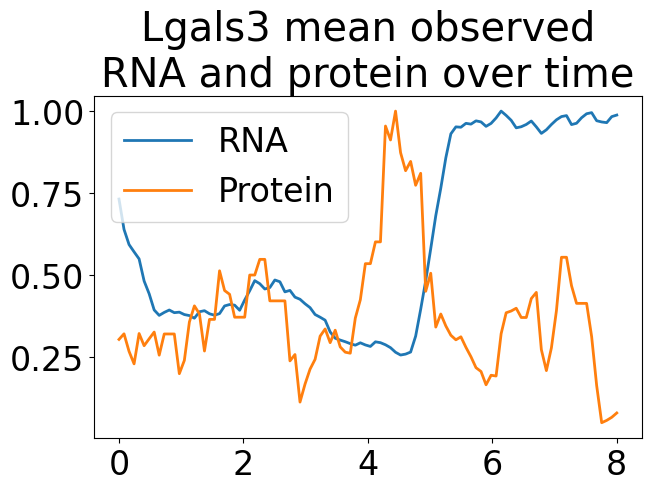

In [197]:
mean_ADT = expr_ADT_ordered[prot].groupby(t_per_cell).mean()
smoothed_ADT = mean_ADT.rolling(window=8, center=True, min_periods=1).mean()

mean_RNA = expr_RNA_ordered[gene].groupby(t_per_cell).mean()
smoothed_RNA = mean_RNA.rolling(window=8, center=True, min_periods=1).mean()

plt.plot(t, smoothed_RNA.values/max(smoothed_RNA.values), linewidth=2, label="RNA")
plt.plot(t, smoothed_ADT.values/max(smoothed_ADT.values), linewidth=2, label="Protein")
plt.legend()
plt.title(f"{gene} mean observed\nRNA and protein over time")

In [198]:
alpha[traj_genes['Gene_symbol'] == gene]

array([[ 90.01263637, 123.89822871,  16.23934708]])

Text(0.5, 1.0, 'Imputed Lgals3 RNA and protein')

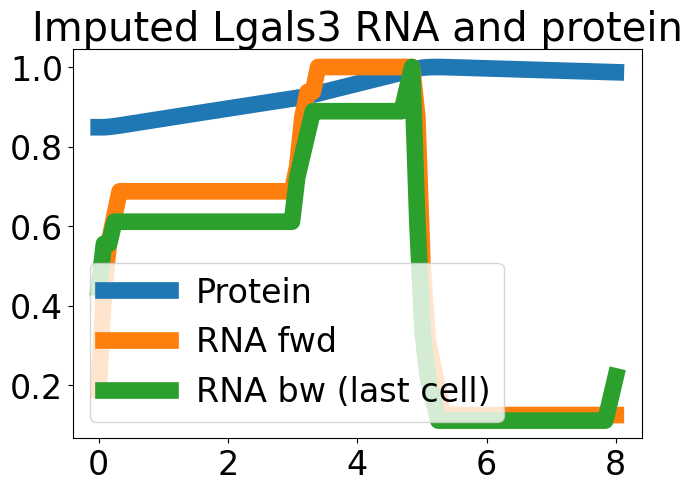

In [199]:
value = gene_order_idx[gene_idx]
X_fwd = X_fwd_per_gene[value]
states = np.asarray(states_per_gene[value]) # Get most probable state for spliced RNA at each time point
Y = states[X_fwd.argmax(axis=0)]

plt.plot(t, P_imputed[:, gene_idx]/max(P_imputed[:, gene_idx]), label="Protein")
plt.plot(t, Y_fwd[:, 1]/max(Y_fwd[:, 1]), label="RNA fwd")
plt.plot(t, Y_bw/max(Y_bw), label="RNA bw (last cell)")
plt.legend()
plt.title(f"Imputed {gene} RNA and protein")

Text(0.5, 1.0, 'Imputed Lgals3 protein')

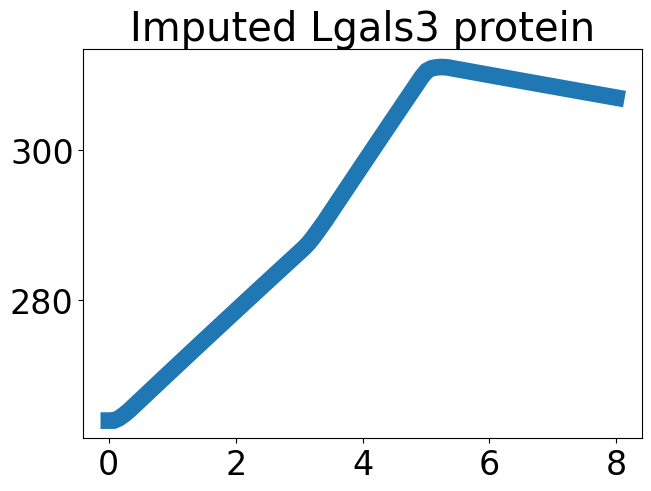

In [200]:
plt.plot(t, P_imputed[:, gene_idx], label="Protein")
plt.title(f"Imputed {gene} protein")

In [186]:
orig_corr[orig_corr['Gene'] == gene]

,Protein,Gene,Cor,Mean_RNA_expr
5,CD107a,Lamp1,0.147878,3.021922


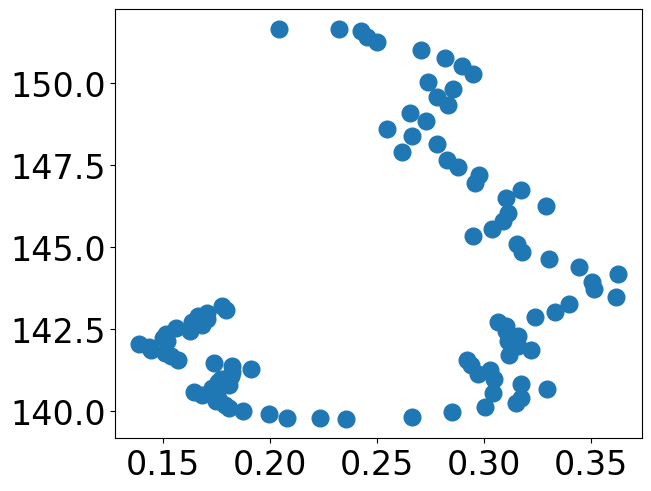

In [187]:
plt.scatter(smoothed_ADT.values.ravel(), P_imputed[:, gene_idx])

In [188]:
np.corrcoef(smoothed_ADT.values.ravel(), P_imputed[:, gene_idx])

array([[1.       , 0.2839539],
       [0.2839539, 1.       ]])

# Compare "ideal" vs. reconstructed protein imputation

In [224]:
# Compare this to imputed protein

with open(f"data/{prefix}_traj_WS.pkl", "rb") as f:
    traj = pickle.load(f)
    
t = traj.t
Q = traj.Q[:, 0, :]

cell_meta = pd.read_csv(f"data/{prefix}_traj_X_row_metadata.csv")
expr_ADT_imputed = pd.read_csv(f"data/{prefix}_RNA_history_imputed_protein.csv")

Q_max_idx = np.argmax(Q, axis=1) # Get index of each cell's place in time
cell_order_idx = np.argsort(Q_max_idx) # Get ordered cells indices
# cell_idx = expr_ADT_imputed.index[cell_order_idx] # Get names of cells ordered by time

expr_ADT_imputed.index = cell_meta['Cell_ID']
expr_ADT_imputed_ordered = expr_ADT_imputed.iloc[cell_order_idx]

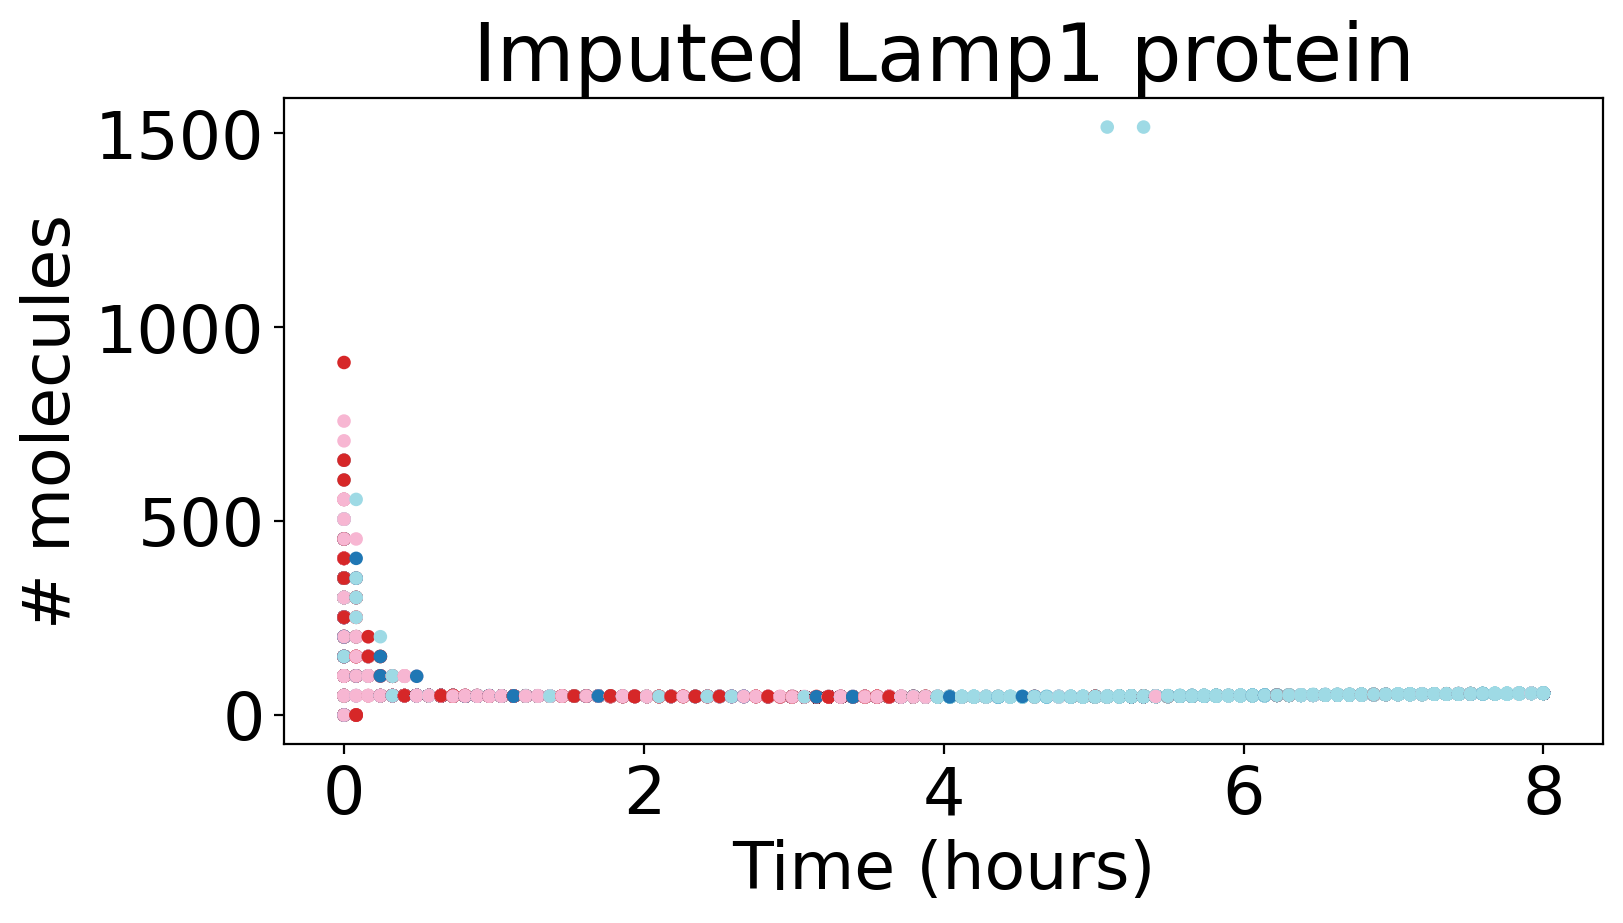

In [253]:
fig, ax = plt.subplots(figsize=(8, 4.5), dpi=200)
ax.scatter(t_per_cell, expr_ADT_imputed_ordered[gene], c=codes, cmap=cmap, s=15, alpha=1)

handles = [
    Line2D([0], [0], marker='o', linestyle='None',
           markerfacecolor=cmap(i), markeredgecolor='none',
           markersize=20, label=str(lbl))  
    for i, lbl in enumerate(labels)
]
 
ax.set_title(f"Imputed {gene} protein")
ax.set_xlabel("Time (hours)")
ax.set_ylabel("# molecules")
plt.show()

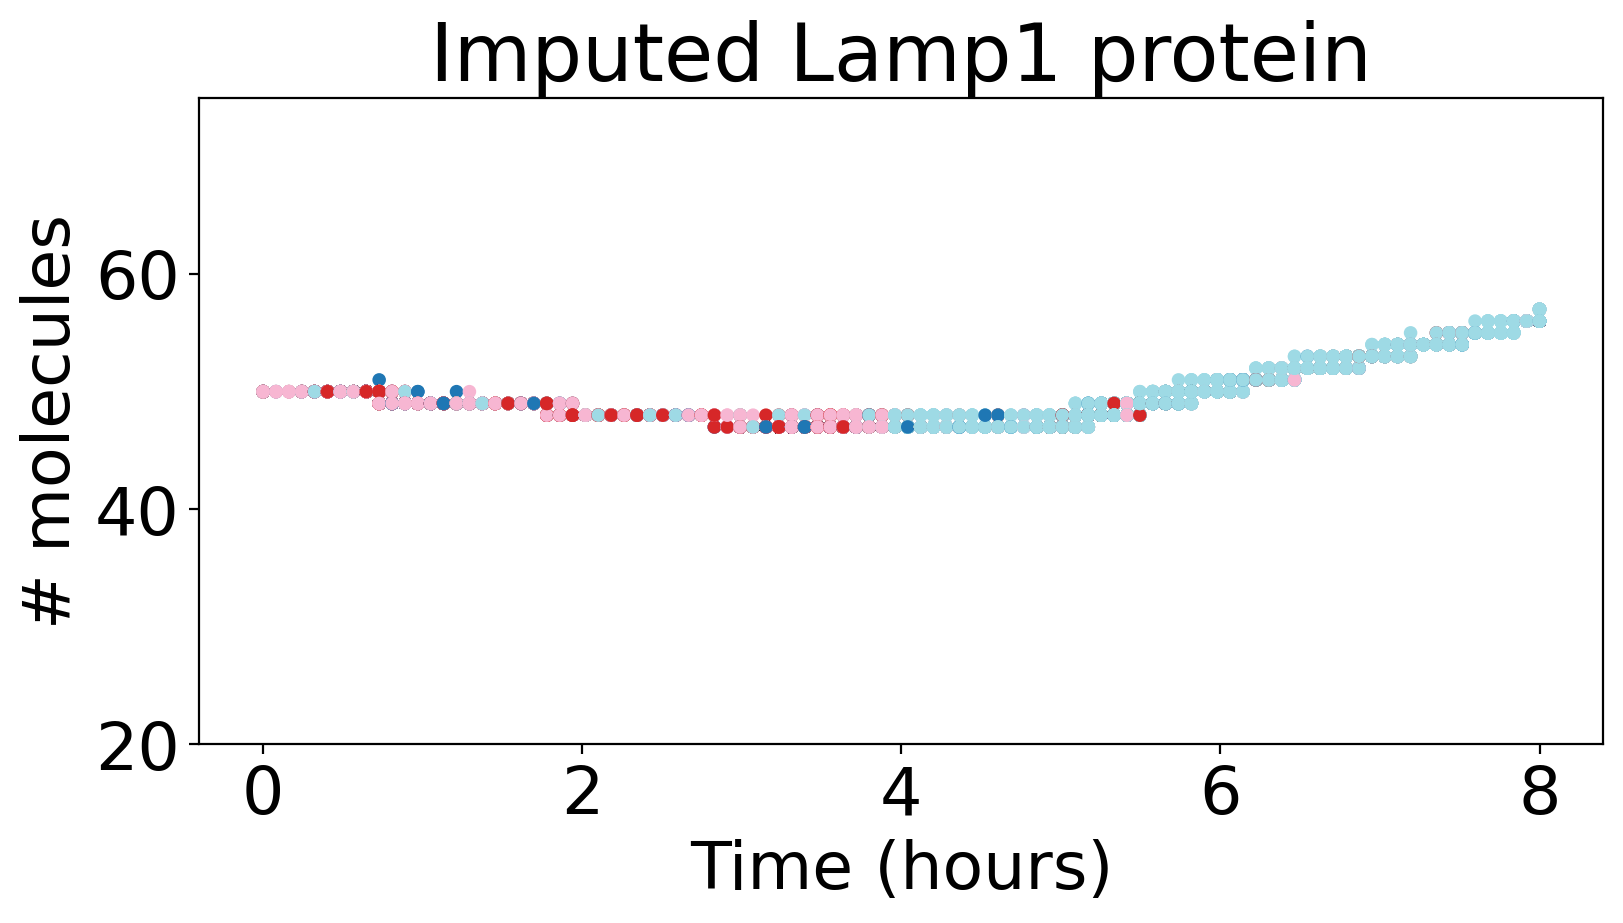

In [52]:
fig, ax = plt.subplots(figsize=(8, 4.5), dpi=200)
ax.scatter(t_per_cell, expr_ADT_imputed_ordered[gene], c=codes, cmap=cmap, s=15, alpha=1)

handles = [
    Line2D([0], [0], marker='o', linestyle='None',
           markerfacecolor=cmap(i), markeredgecolor='none',
           markersize=20, label=str(lbl))  
    for i, lbl in enumerate(labels)
]
 
ax.set_title(f"Imputed {gene} protein")
ax.set_xlabel("Time (hours)")
ax.set_ylabel("# molecules")

ax.set_ylim(20, 75)
plt.show()

## Why are we getting different protein levels for "ideal" vs. "reconstructed" RNAs?

In [ ]:
# Format RNA from simulated forward trajectory

idx = gene_idx
value = gene_order_idx[idx]

X_fwd = X_fwd_per_gene[value]
states = np.asarray(states_per_gene[value])
Y_fwd = states[X_fwd.argmax(axis=0)][:, 1]

transl_rate = 1
deg_rate = median_deg[idx]

In [234]:
# Format RNA from backward reconstructing for working gene

file_path = f"data/RNA_history_per_gene/{prefix}_{gene}_S_RNA_history.pkl"

with open(file_path, "rb") as f:
    X_bw = pickle.load(f)

X_bw_ordered = X_bw[cell_order_idx, :] # Order cells by time 
Y_bw = X_bw_ordered[-1, :]

In [237]:
# Choose last time point (since we have full trajectory)

Y = Y_fwd
Q_max_idx = -1
y0 = Y[0] # Steady-state RNA abundance (RNA at start of first interval)
ss_rate = transl_rate / deg_rate # Definition of steady-state protein production rate 
p0 = ss_rate * y0 # Protein at start of first interval 
p_old = p0 * np.exp(-deg_rate * t[Q_max_idx]) # Protein from start of first interval that survived per cell

dt = np.concatenate([np.diff(t), [0.0]])
X_bw_clean = np.where(Y < 0, 0, Y) # clean -1 placeholders (X_bw was populated with '-1' for time points after the cell was observed)
X_bw_dt = Y * dt # Multiply each timepoint's RNA by its corresponding time step size (Riemann approximation) 

# Protein produced over start of trajectory to the time a cell was sampled
t_reshape = t.reshape((-1, 1))
t_diff = t_reshape.T - t_reshape
t_diff = t_diff[:, Q_max_idx] # Each column contains time steps up to cell's observed time
mask = (t_diff > 0)  
decay_matrix = np.exp(-np.maximum(t_diff, 0) * deg_rate)
decay_matrix = np.where(mask, decay_matrix, 0) # decay_matrix[i, m]: decay factor for protein at t[m] from RNA available at t[i] in cell m 

p_new = (decay_matrix * X_bw_dt.T).sum(axis=0) # Integrate protein counts from each interval
P = p_old + p_new # Protein abundance in each cell = pre-existing protein + newly synthesized protein

P

np.float64(99.82788285917825)

In [240]:
Y = Y_bw
Q_max_idx = -1
y0 = Y[0] # Steady-state RNA abundance (RNA at start of first interval)
ss_rate = transl_rate / deg_rate # Definition of steady-state protein production rate 
p0 = ss_rate * y0 # Protein at start of first interval 
p_old = p0 * np.exp(-deg_rate * t[Q_max_idx]) # Protein from start of first interval that survived per cell

dt = np.concatenate([np.diff(t), [0.0]])
X_bw_clean = np.where(Y < 0, 0, Y) # clean -1 placeholders (X_bw was populated with '-1' for time points after the cell was observed)
X_bw_dt = Y * dt # Multiply each timepoint's RNA by its corresponding time step size (Riemann approximation) 

# Protein produced over start of trajectory to the time a cell was sampled
t_reshape = t.reshape((-1, 1))
t_diff = t_reshape.T - t_reshape
t_diff = t_diff[:, Q_max_idx] # Each column contains time steps up to cell's observed time
mask = (t_diff > 0)  
decay_matrix = np.exp(-np.maximum(t_diff, 0) * deg_rate)
decay_matrix = np.where(mask, decay_matrix, 0) # decay_matrix[i, m]: decay factor for protein at t[m] from RNA available at t[i] in cell m 

p_new = (decay_matrix * X_bw_dt.T).sum(axis=0) # Integrate protein counts from each interval
P = p_old + p_new # Protein abundance in each cell = pre-existing protein + newly synthesized protein

P

np.float64(56.690746668079115)

In [241]:
print(Y_fwd)

print(Y_bw)

[2 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 3 3 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4]
[1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 3 3 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 5 6]


Text(0, 0.5, 'Backward reconstruction')

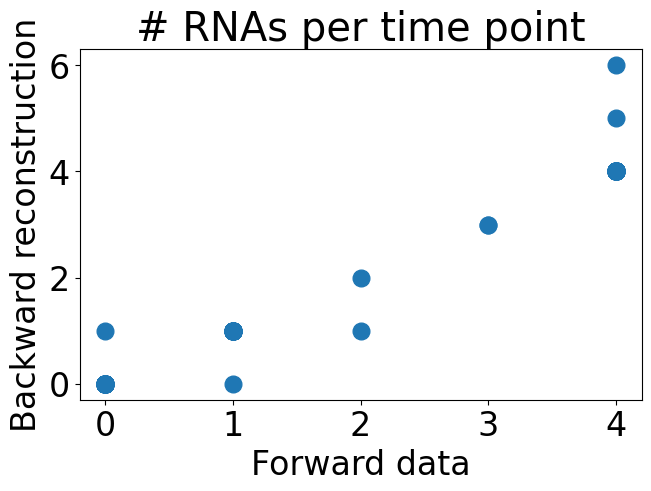

In [256]:
plt.scatter(Y_fwd, Y_bw)
plt.title("# RNAs per time point")
plt.xlabel("Forward data")
plt.ylabel("Backward reconstruction")

### Looks like it's just a function of slightly differing amounts of RNA over time...